Matplotlib is building the font cache; this may take a moment.


--- DATA SHAPE ---
(150, 6)

--- DATA TYPES ---
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

--- NULL VALUE CHECK ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

--- DESCRIPTIVE STATISTICS ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4

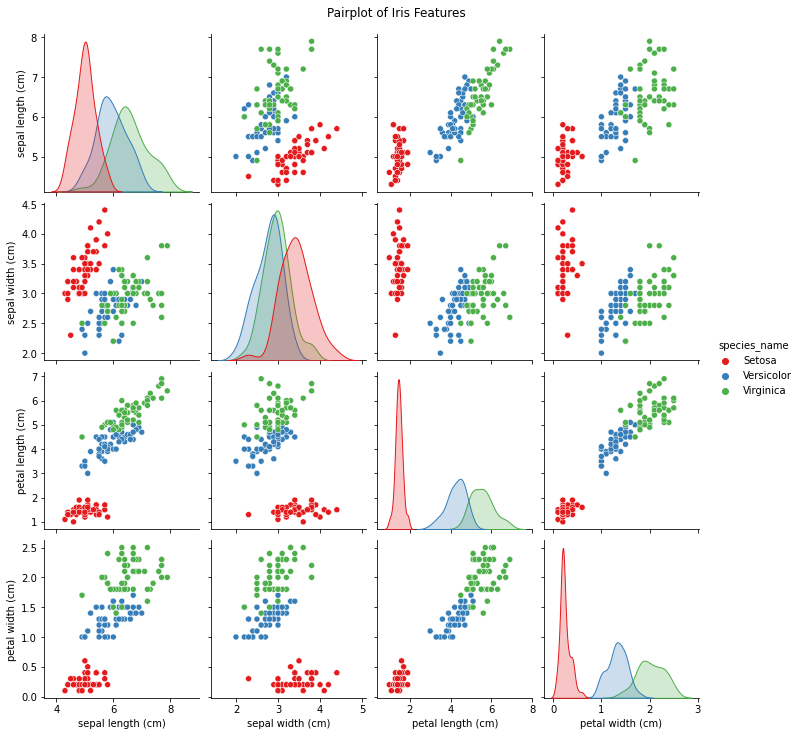

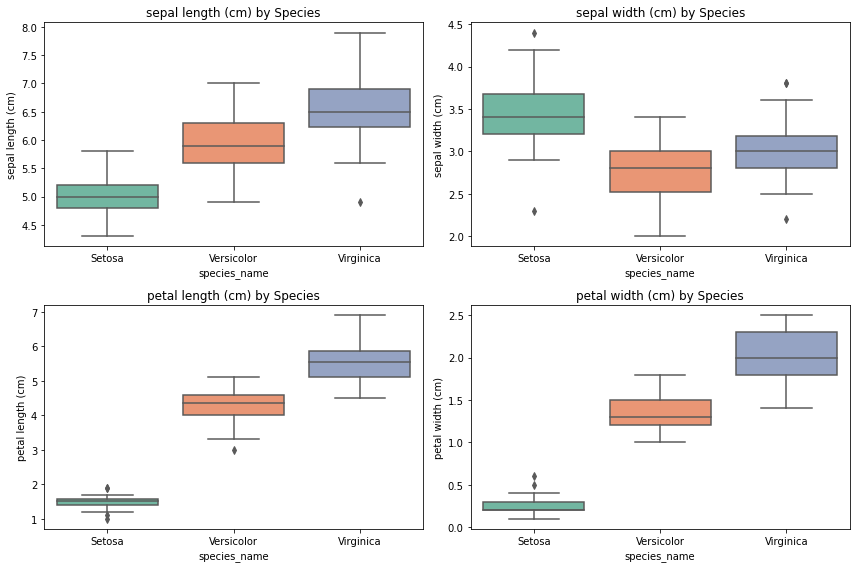


=== MODEL 1: LOGISTIC REGRESSION ===
Accuracy Score: 1.0000

=== MODEL 2: RANDOM FOREST ===
Accuracy Score: 1.0000


In [1]:
# ==========================================
# STEP 1: LOAD THE LIBRARIES AND DATASET
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load the built-in Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

# ==========================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("--- DATA SHAPE ---")
print(df.shape)

print("\n--- DATA TYPES ---")
print(df.dtypes)

print("\n--- NULL VALUE CHECK ---")
print(df.isnull().sum())

print("\n--- DESCRIPTIVE STATISTICS ---")
print(df.describe())

# ==========================================
# STEP 3: VISUALISATIONS
# ==========================================
sns.pairplot(df, vars=iris.feature_names, hue='species_name', palette='Set1')
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

plt.figure(figsize=(12, 8))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='species_name', y=feature, data=df, palette='Set2')
    plt.title(f'{feature} by Species')
plt.tight_layout()
plt.show()

# ==========================================
# STEP 4: TRAIN/TEST SPLIT
# ==========================================
X = df[iris.feature_names]
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# ==========================================
# STEP 5 & 6: TRAIN & EVALUATE CLASSIFIERS
# ==========================================
print("\n=== MODEL 1: LOGISTIC REGRESSION ===")
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, lr_preds):.4f}")

print("\n=== MODEL 2: RANDOM FOREST ===")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, rf_preds):.4f}")